# **Import Labraries**

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import joblib

# **Data Exploration & Preprocessing**

# Load the Dataset

In [3]:
dataset=pd.read_csv(r"train (1).csv")


#  Display Shape

In [4]:
print(dataset.shape)

(1460, 81)


# Display describe()

In [5]:
print(dataset.describe())

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.066207   456.098091  ..

#  Display Data types

In [6]:
print(dataset.dtypes)

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object


# Identify and handle missing values

In [7]:
missing_values=dataset.isnull().sum()
print(missing_values)

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [8]:
for col in dataset.select_dtypes(include=np.number).columns:
    dataset[col] = dataset[col].fillna(dataset[col].median())

for col in dataset.select_dtypes(include=["object", "string"]).columns:
    dataset[col] = dataset[col].fillna(dataset[col].mode()[0])

print("Missing values:", dataset.isnull().sum().sum())


Missing values: 0


#  Detect and handle outliers

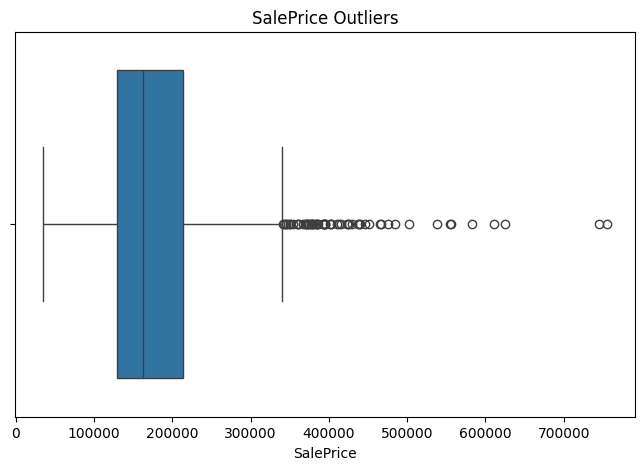

(1399, 81)


In [9]:
#Outlier Detection
plt.figure(figsize=(8,5))
sns.boxplot(x=dataset["SalePrice"])
plt.title("SalePrice Outliers")
plt.show()

#Outlier Handling
Q1 = dataset["SalePrice"].quantile(0.25)
Q3 = dataset["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

dataset = dataset[
    (dataset["SalePrice"] >= lower) &
    (dataset["SalePrice"] <= upper)
]

print(dataset.shape)

# Histogram Plot

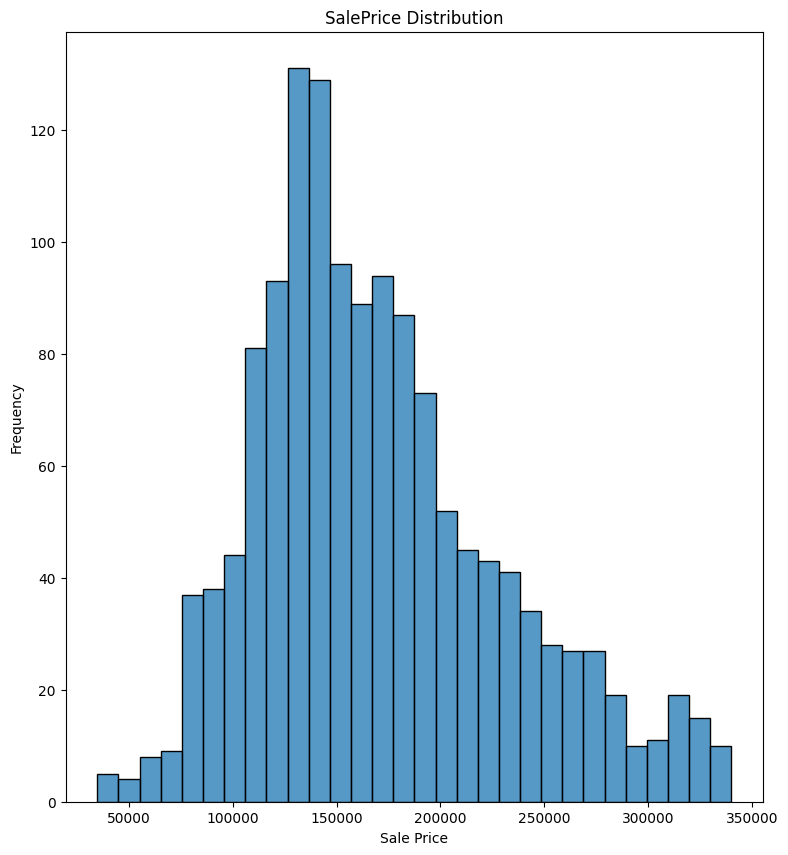

In [10]:
plt.figure(figsize=(9,10))
sns.histplot(dataset["SalePrice"], bins=30)     # Numeric Value

plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("SalePrice Distribution")

plt.show()

#  ScatterPlot

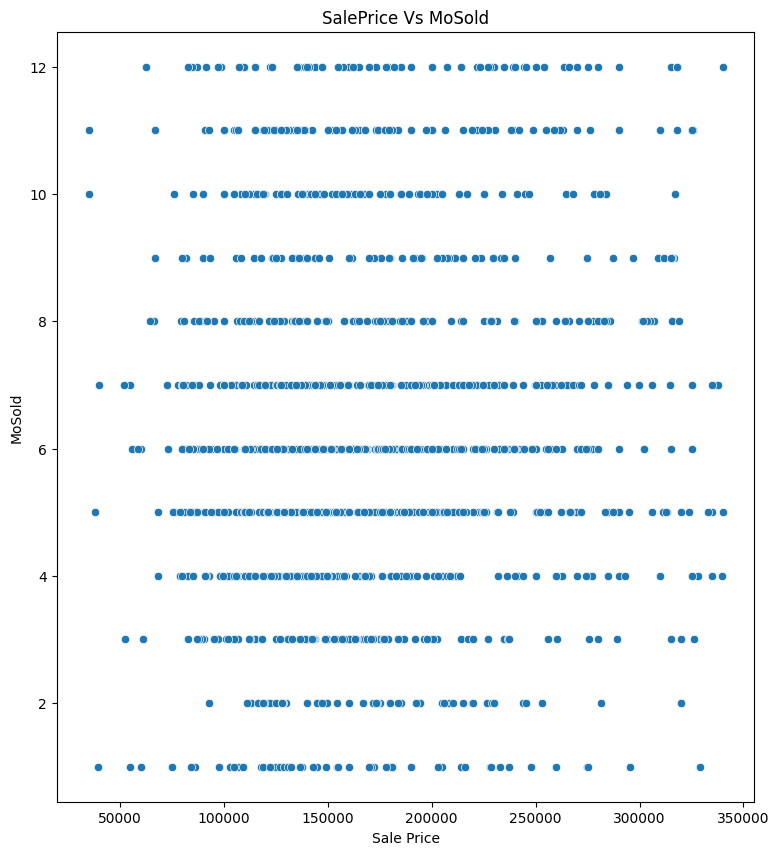

In [11]:
plt.figure(figsize=(9,10))

sns.scatterplot(
    x=dataset["SalePrice"],            # Numeric Value
    y=dataset["MoSold"]                # Numeric Value
)

plt.xlabel("Sale Price")
plt.ylabel("MoSold")
plt.title("SalePrice Vs MoSold")

plt.show()

#  BarPlot

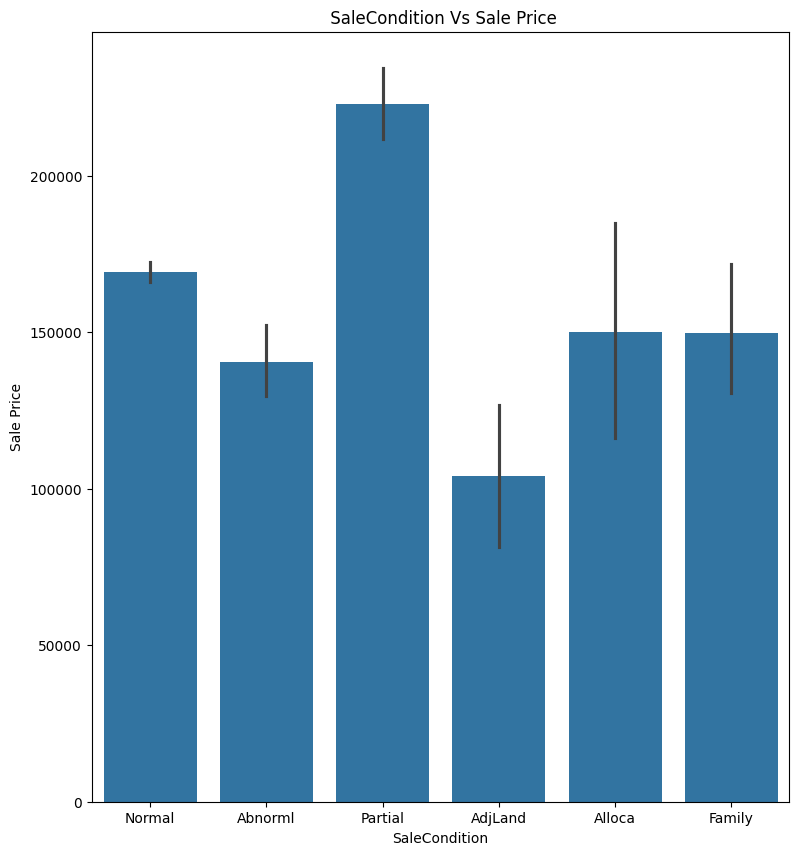

In [12]:
plt.figure(figsize=(9,10))

sns.barplot(
    y=dataset["SalePrice"],                     # Numeric value
    x=dataset["SaleCondition"]                  # Categorical value
)

plt.ylabel("Sale Price")
plt.xlabel("SaleCondition")
plt.title(" SaleCondition Vs Sale Price")

plt.show()


#  BoxPLot

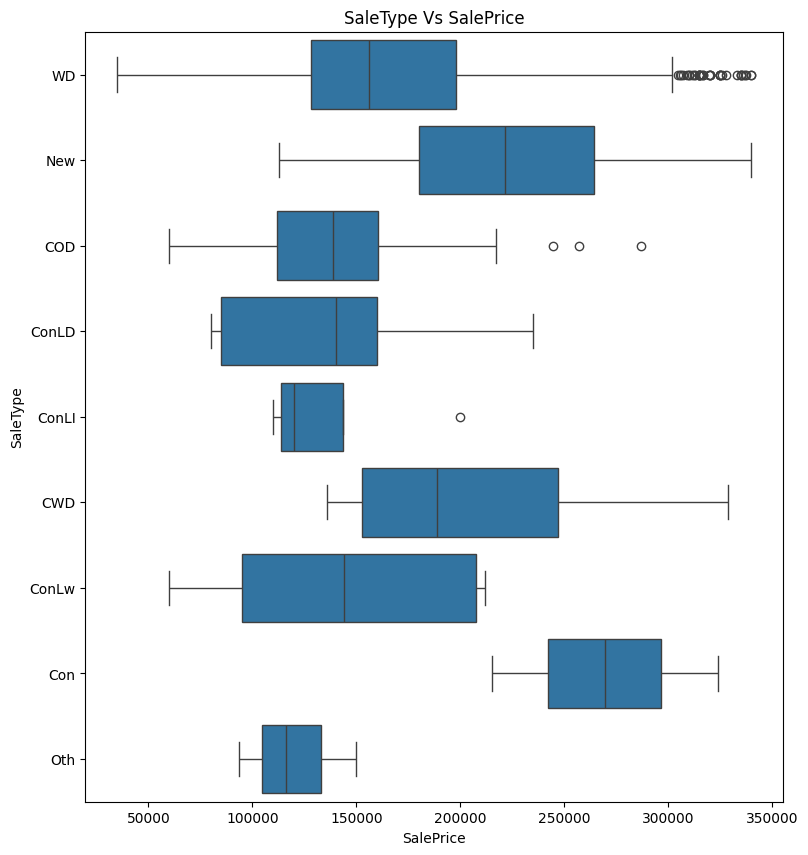

In [13]:
plt.figure(figsize=(9,10))

sns.boxplot(
    y=dataset["SaleType"],      # categorical
    x=dataset["SalePrice"]      # numeric
)

plt.title("SaleType Vs SalePrice")

plt.show()

#  Heatmap

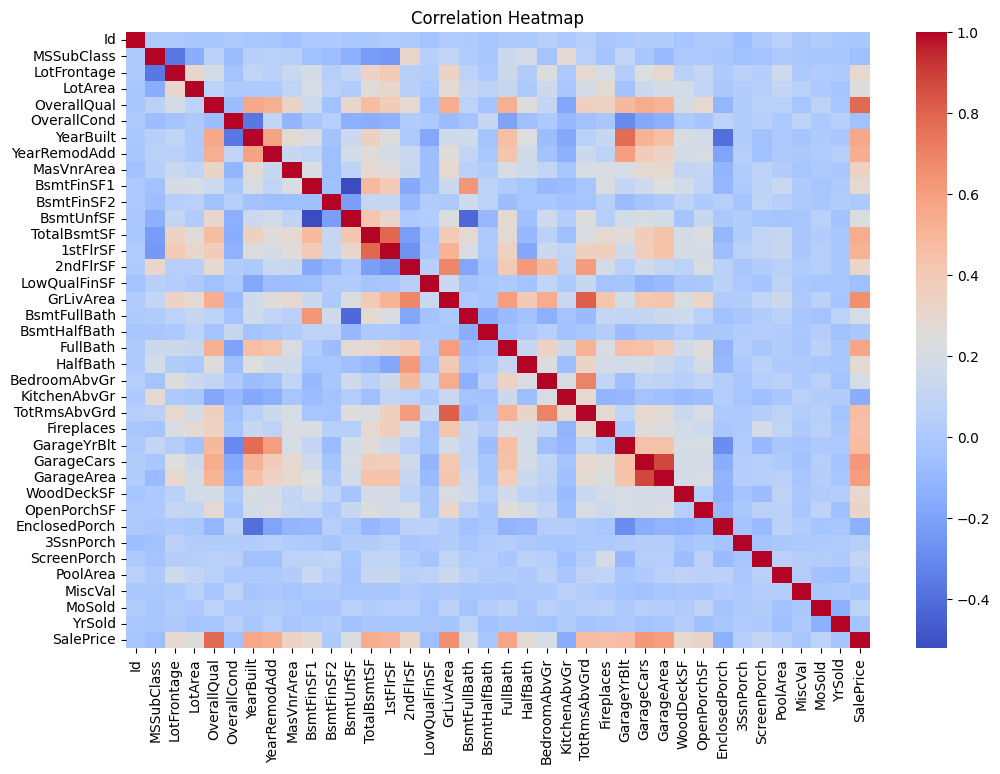

In [14]:
plt.figure(figsize=(12,8))

corr = dataset.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

#  Encode categorical variables if needed

In [20]:
dataset = pd.get_dummies(
    dataset,
    drop_first=True
)

dataset.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


 # Correlation Check

In [22]:
corr = dataset.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
print(corr.head(10))

SalePrice       1.000000
OverallQual     0.784294
GrLivArea       0.661325
GarageCars      0.628013
GarageArea      0.607230
ExterQual_Gd    0.588472
FullBath        0.577369
YearBuilt       0.564558
TotalBsmtSF     0.543508
YearRemodAdd    0.541161
Name: SalePrice, dtype: float64


# **Model NO 1-  Simple Linear Regression**

In [23]:
X = dataset[["OverallQual"]]
y = dataset["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

#  Train a Simple Linear Regression model

In [24]:
model_simple = LinearRegression()
model_simple.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[35849.56]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['OverallQual']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.424e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [25]:
y_pred=model_simple.predict(X_test)
print("ActualValues:")
print(y_test)
print("\nPredictedValues")
print(y_pred)

ActualValues:
398      67000
435     212000
183     200000
1339    128500
970     135000
         ...  
1360    189000
219     167240
623     168500
411     145000
44      141000
Name: SalePrice, Length: 280, dtype: int64

PredictedValues
[135011.31484501 206710.43750293 206710.43750293 135011.31484501
  99161.75351605 135011.31484501 135011.31484501 170860.87617397
  63312.19218709 242559.99883189 170860.87617397 278409.56016085
  63312.19218709  99161.75351605 170860.87617397 135011.31484501
 206710.43750293 170860.87617397 135011.31484501 170860.87617397
 135011.31484501 170860.87617397 170860.87617397 135011.31484501
 135011.31484501 206710.43750293 206710.43750293 135011.31484501
 170860.87617397 170860.87617397 135011.31484501 135011.31484501
 206710.43750293 135011.31484501 135011.31484501 206710.43750293
 206710.43750293 170860.87617397 206710.43750293  99161.75351605
 170860.87617397 170860.87617397  99161.75351605 135011.31484501
 135011.31484501 170860.87617397 135011.314845

#  Plot the regression line on a scatter plot

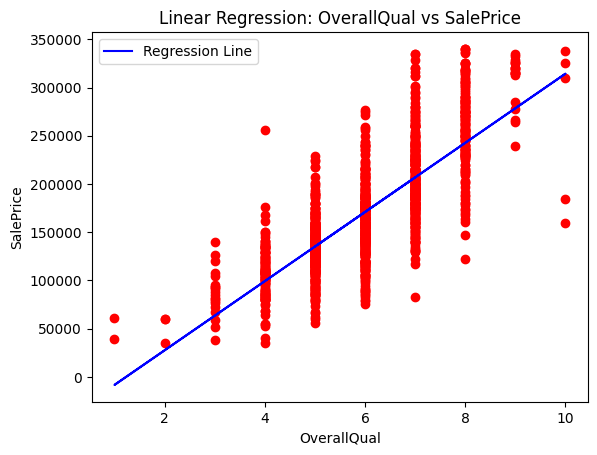

In [26]:
plt.scatter(
    dataset["OverallQual"],
    dataset["SalePrice"],
    color="red"
)

plt.plot(
    dataset["OverallQual"],
    model_simple.predict(dataset[["OverallQual"]]),
    color="blue",
    label="Regression Line"
)

plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Linear Regression: OverallQual vs SalePrice")
plt.legend()
plt.show()

# Evaluate using: MAE, MSE and R² ScoreEvaluation

In [27]:
mae_simple = mean_absolute_error(
    y_test,
    y_pred
)

mse_simple = mean_squared_error(
    y_test,
    y_pred
)

r2_simple = r2_score(
    y_test,
    y_pred
)

print("MAE =",mae_simple)
print("MSE =",mse_simple)
print("R2 =",r2_simple)


MAE = 27806.097784649042
MSE = 1226331870.4496434
R2 = 0.6406150460305247


# **Model No 2: Multiple Linear Regression**

In [28]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd"
]
X = dataset[features]
y = dataset["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)
    

#  Train a Multiple Linear Regression model

In [29]:
model_multiple= LinearRegression()
model_multiple.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[15160.78, 36.23,10685.58,..., 486.89, 306.62, 307.99]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['OverallQual','GrLivArea','GarageCars',...,'TotRmsAbvGrd','YearBuilt', 'YearRemodAdd']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.232e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10


In [30]:
y_pred=model_multiple.predict(X_test)
print("ActualValues:")
print(y_test)
print("\nPredictedValues")
print(y_pred)

ActualValues:
1159    185000
325      87000
819     224000
516     158000
1111    205000
         ...  
1160    146000
310     165600
519     234000
503     289000
829     147400
Name: SalePrice, Length: 280, dtype: int64

PredictedValues
[184313.39761288 108133.69305234 208523.17598743 193553.77707799
 203621.58854068 134489.9550458  191164.69474037 172759.97629194
 267279.91662764 115770.05353714  81750.29356968 148586.80975592
 108714.44606665 155115.83740962 135080.48973038 114668.55309112
 240562.7702616  126152.10994404 100452.05129886 212109.97410274
 157543.12908088 111095.44804715 112627.5685359  202354.4516822
 143564.20814561 112961.21221493 141616.26959419 130254.09769372
 240295.49752409 229996.79164466 225130.08974884 115527.94150908
  86991.66369037 214988.67371821 206927.74743915 212398.94217661
 107302.75715862 221433.62709746 100331.142317   215980.24972512
 134822.70879845 289300.95796602 247484.38582583 138311.6720038
 157425.12623866 169984.31610173 159307.96089128

# Display model coefficients and interpret them

In [31]:
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_multiple.coef_
})

print(coef_table)

        Feature   Coefficient
0   OverallQual  15160.783816
1     GrLivArea     36.232086
2    GarageCars  10685.583724
3    GarageArea     11.497291
4   TotalBsmtSF      9.152789
5      1stFlrSF      8.271497
6      FullBath  -1713.184360
7  TotRmsAbvGrd    486.890213
8     YearBuilt    306.620471
9  YearRemodAdd    307.989762


# Evaluate using: MAE, MSE and R² Score

In [32]:
mae_multiple = mean_absolute_error(
    y_test,
    y_pred
)

mse_multiple = mean_squared_error(
    y_test,
    y_pred
)

r2_multiple = r2_score(
    y_test,
    y_pred
)

print("MAE =",mae_multiple)
print("MSE =",mse_multiple)
print("R2 =",r2_multiple)


MAE = 21498.805230680147
MSE = 819120732.1893734
R2 = 0.7871317814786137


# **Model NO 3: Polynomial Regression**

# Use the same feature chosen in Simple Linear Regression

In [33]:
X = dataset[["OverallQual"]]

y = dataset["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

# Train Polynomial Regression models with degree 2 

In [34]:
poly2 = PolynomialFeatures(degree=2)

X_train_poly2 = poly2.fit_transform(X_train)

X_test_poly2 = poly2.transform( X_test)

In [35]:
model_poly2 = LinearRegression()

model_poly2.fit(
    X_train_poly2,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0. ,4958.03,2602.22]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.289e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[511.14, 6.3 , 0. ]"


In [36]:
y_pred_poly2 = model_poly2.predict(X_test_poly2)
print("ActualValues:")
print(y_test)
print("\nPredictedValues")
print(y_pred_poly2)

ActualValues:
1159    185000
325      87000
819     224000
516     158000
1111    205000
         ...  
1160    146000
310     165600
519     234000
503     289000
829     147400
Name: SalePrice, Length: 280, dtype: int64

PredictedValues
[166316.16171357 132733.71490426 205103.04825576 166316.16171357
 205103.04825576 132733.71490426 205103.04825576 132733.71490426
 298290.14053877 104355.70782782 132733.71490426 166316.16171357
 132733.71490426 132733.71490426 132733.71490426 104355.70782782
 249094.37453082 132733.71490426 104355.70782782 205103.04825576
 166316.16171357 104355.70782782 132733.71490426 166316.16171357
 132733.71490426 132733.71490426 166316.16171357 132733.71490426
 205103.04825576 249094.37453082 249094.37453082 132733.71490426
 104355.70782782 205103.04825576 166316.16171357 205103.04825576
  81182.14048427 249094.37453082 132733.71490426 249094.37453082
 166316.16171357 298290.14053877 249094.37453082 132733.71490426
 132733.71490426 166316.16171357 132733.714904

# Train Polynomial Regression models with degree 3

In [37]:
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform( X_train)

X_test_poly3 = poly3.transform(X_test)

In [38]:
model_poly3 = LinearRegression()

model_poly3.fit(
    X_train_poly3,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. ,-43773.4 , 11426.31, -506.38]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.275e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[4942.07, 67.12, 1.98, 0. ]"


In [39]:
y_pred_poly3 = model_poly3.predict(X_test_poly3)
print("ActualValues:")
print(y_test)
print("\nPredictedValues")
print(y_pred_poly3)

ActualValues:
1159    185000
325      87000
819     224000
516     158000
1111    205000
         ...  
1160    146000
310     165600
519     234000
503     289000
829     147400
Name: SalePrice, Length: 280, dtype: int64

PredictedValues
[166841.47657305 131005.62279685 207300.44374912 166841.47657305
 207300.44374912 131005.62279685 207300.44374912 131005.62279685
 289934.71626512 102831.13292949 131005.62279685 166841.47657305
 131005.62279685 131005.62279685 131005.62279685 102831.13292949
 249344.27381613 131005.62279685 102831.13292949 207300.44374912
 166841.47657305 102831.13292949 131005.62279685 166841.47657305
 131005.62279685 131005.62279685 166841.47657305 131005.62279685
 207300.44374912 249344.27381613 249344.27381613 131005.62279685
 102831.13292949 207300.44374912 166841.47657305 207300.44374912
  85356.25747991 249344.27381613 131005.62279685 249344.27381613
 166841.47657305 289934.71626512 249344.27381613 131005.62279685
 131005.62279685 166841.47657305 131005.622796

# Evaluate using: MAE, MSE and R² Score

In [40]:
mae_poly2 = mean_absolute_error(
    y_test,
    y_pred_poly2
)

mse_poly2 = mean_squared_error(
    y_test,
    y_pred_poly2
)

r2_poly2 = r2_score(
    y_test,
    y_pred_poly2
)

print("Degree 2")
print(mae_poly2)
print(mse_poly2)
print(r2_poly2)


Degree 2
27585.805251044094
1303312926.6451073
0.6613027970500716


In [41]:
mae_poly3 = mean_absolute_error(
    y_test,
    y_pred_poly3
)

mse_poly3 = mean_squared_error(
    y_test,
    y_pred_poly3
)

r2_poly3 = r2_score(
    y_test,
    y_pred_poly3
)

print("Degree 3")
print(mae_poly3)
print(mse_poly3)
print(r2_poly3)

Degree 3
27830.200798524012
1324426988.127976
0.6558158004731491


# Plot all curves (Linear, Poly-2, Poly-3) on the same graph for comparison

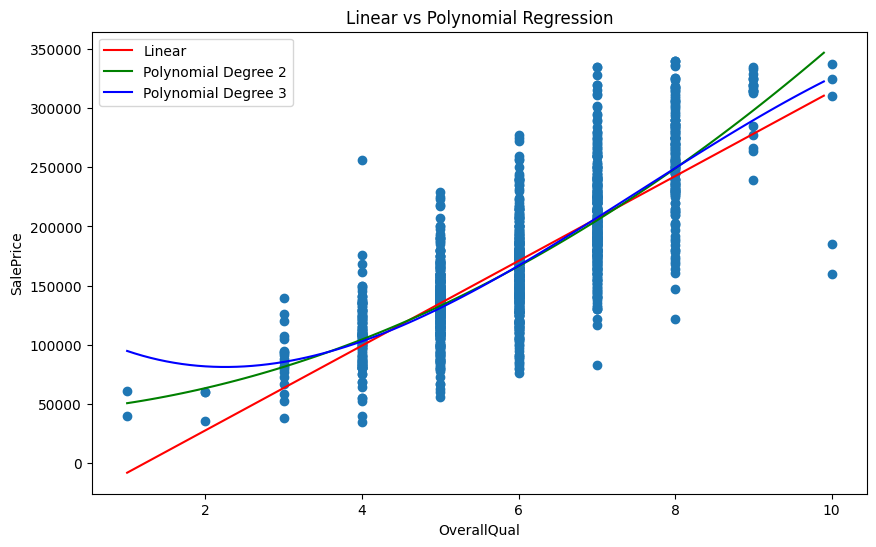

In [42]:
X_grid = pd.DataFrame({
    'OverallQual': np.arange(
        X['OverallQual'].min(),
        X['OverallQual'].max(),
        0.1
    )
})

plt.figure(figsize=(10,6))

plt.scatter(X, y)

plt.plot(
    X_grid,
    model_simple.predict(X_grid),
    color='red',
    label='Linear'
)

plt.plot(
    X_grid,
    model_poly2.predict(poly2.transform(X_grid)),
    color='green',
    label='Polynomial Degree 2'
)

plt.plot(
    X_grid,
    model_poly3.predict(poly3.transform(X_grid)),
    color='blue',
    label='Polynomial Degree 3'
)

plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.title('Linear vs Polynomial Regression')
plt.legend()
plt.show()

# **Model Comparison**

In [43]:
comparison = pd.DataFrame({
    "Model":[
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Degree 2",
        "Polynomial Degree 3"
    ],
    "MAE":[
        mae_simple,
        mae_multiple,
        mae_poly2,
        mae_poly3
    ],
    "MSE":[
        mse_simple,
        mse_multiple,
        mse_poly2,
        mse_poly3
    ],
    "R2 Score":[
        r2_simple,
        r2_multiple,
        r2_poly2,
        r2_poly3
    ],
    
})

print(comparison)

                        Model           MAE           MSE  R2 Score
0    Simple Linear Regression  27806.097785  1.226332e+09  0.640615
1  Multiple Linear Regression  21498.805231  8.191207e+08  0.787132
2         Polynomial Degree 2  27585.805251  1.303313e+09  0.661303
3         Polynomial Degree 3  27830.200799  1.324427e+09  0.655816


# Save Model

In [46]:
joblib.dump(model_multiple, "final_model.pkl")

['final_model.pkl']

# Conclusion